# 04 — Results and spatial transfer

**What this notebook establishes:** the study's findings across all 13
variables, and whether a globally pooled model transfers to ocean it never saw.

This notebook reads the committed experiment output
(`backend/models/forecasting/_reports/paper/`), produced by
`backend/scripts/run_paper_experiments.py --all` — 52 models and 1,248
held-out fits, about 87 minutes of compute. It is not re-run here.

In [1]:
import marisviz as mv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mv.setup()

main, loso, meta = mv.load_results()
print(f"{main['variable'].nunique()} variables | {len(main)} models "
      f"| {len(loso):,} held-out fits")
print(f"snapshot {meta['as_of']} | climatology window +/-{meta['climatology_window_days']} d")

13 variables | 52 models | 1,248 held-out fits
snapshot 2026-08-10 | climatology window +/-15 d


## The headline: two baselines, opposite conclusions

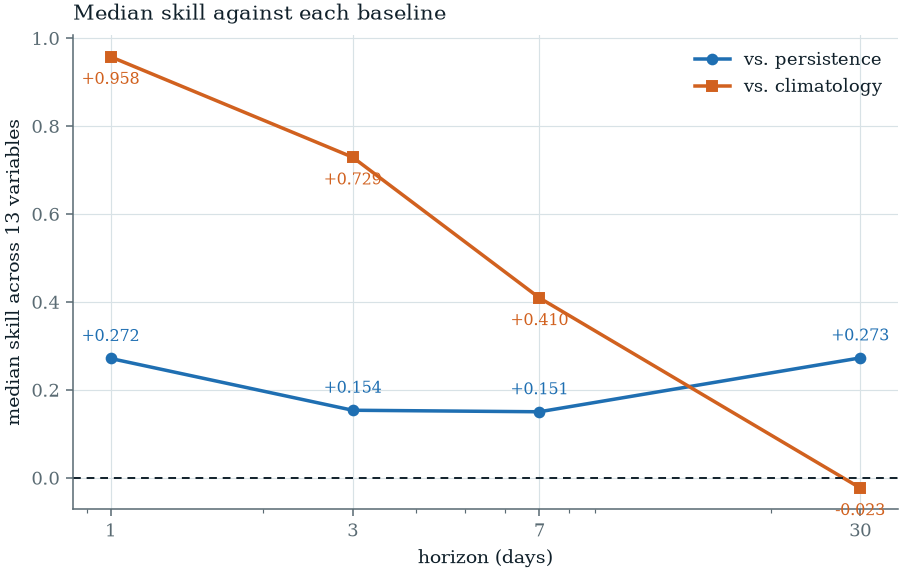

,skill_p,skill_c
horizon,,
1,0.272,0.958
3,0.154,0.729
7,0.151,0.410
30,0.273,-0.023


In [2]:
HORIZONS = [1, 3, 7, 30]
medians = main.groupby("horizon")[["skill_p", "skill_c"]].median().reindex(HORIZONS)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(medians.index, medians["skill_p"], marker="o", color=mv.PERSISTENCE,
        label="vs. persistence")
ax.plot(medians.index, medians["skill_c"], marker="s", color=mv.CLIMATOLOGY,
        label="vs. climatology")
ax.axhline(0, color=mv.INK, linewidth=1.0, linestyle=(0, (4, 3)))
ax.set_xscale("log"); ax.set_xticks(HORIZONS)
ax.set_xticklabels([str(h) for h in HORIZONS])
for h in HORIZONS:
    ax.annotate(f"{medians.loc[h, 'skill_p']:+.3f}", (h, medians.loc[h, "skill_p"]),
                xytext=(0, 9), textcoords="offset points", ha="center",
                fontsize=8, color=mv.PERSISTENCE)
    ax.annotate(f"{medians.loc[h, 'skill_c']:+.3f}", (h, medians.loc[h, "skill_c"]),
                xytext=(0, -14), textcoords="offset points", ha="center",
                fontsize=8, color=mv.CLIMATOLOGY)
ax.set(xlabel="horizon (days)", ylabel="median skill across 13 variables",
       title="Median skill against each baseline")
ax.legend()
mv.save(fig, "04_headline")
plt.show()
medians.round(3)

Median skill against persistence is **essentially unchanged** from 1 to
30 days. Read alone, that says the models are as good at a month as at a day —
for a forecasting system, a remarkable claim.

Median skill against climatology falls **monotonically**, and crosses below
zero by 30 days. Same predictions, opposite conclusions.

In [3]:
summary = pd.DataFrame({
    "median S_pers": main.groupby("horizon")["skill_p"].median(),
    "median S_clim": main.groupby("horizon")["skill_c"].median(),
    "variables losing to persistence": main[main["skill_p"] < 0].groupby("horizon").size(),
    "variables losing to climatology": main[main["skill_c"] < 0].groupby("horizon").size(),
}).reindex(HORIZONS).fillna(0).astype({"variables losing to persistence": int,
                                       "variables losing to climatology": int})
summary.round(3)

,median S_pers,median S_clim,variables losing to persistence,variables losing to climatology
horizon,,,,
1,0.272,0.958,0,0
3,0.154,0.729,2,0
7,0.151,0.410,2,4
30,0.273,-0.023,1,7


## Every variable, both baselines

The climatology curve falls in **every single panel**. The persistence curve is
flat or rising in most.

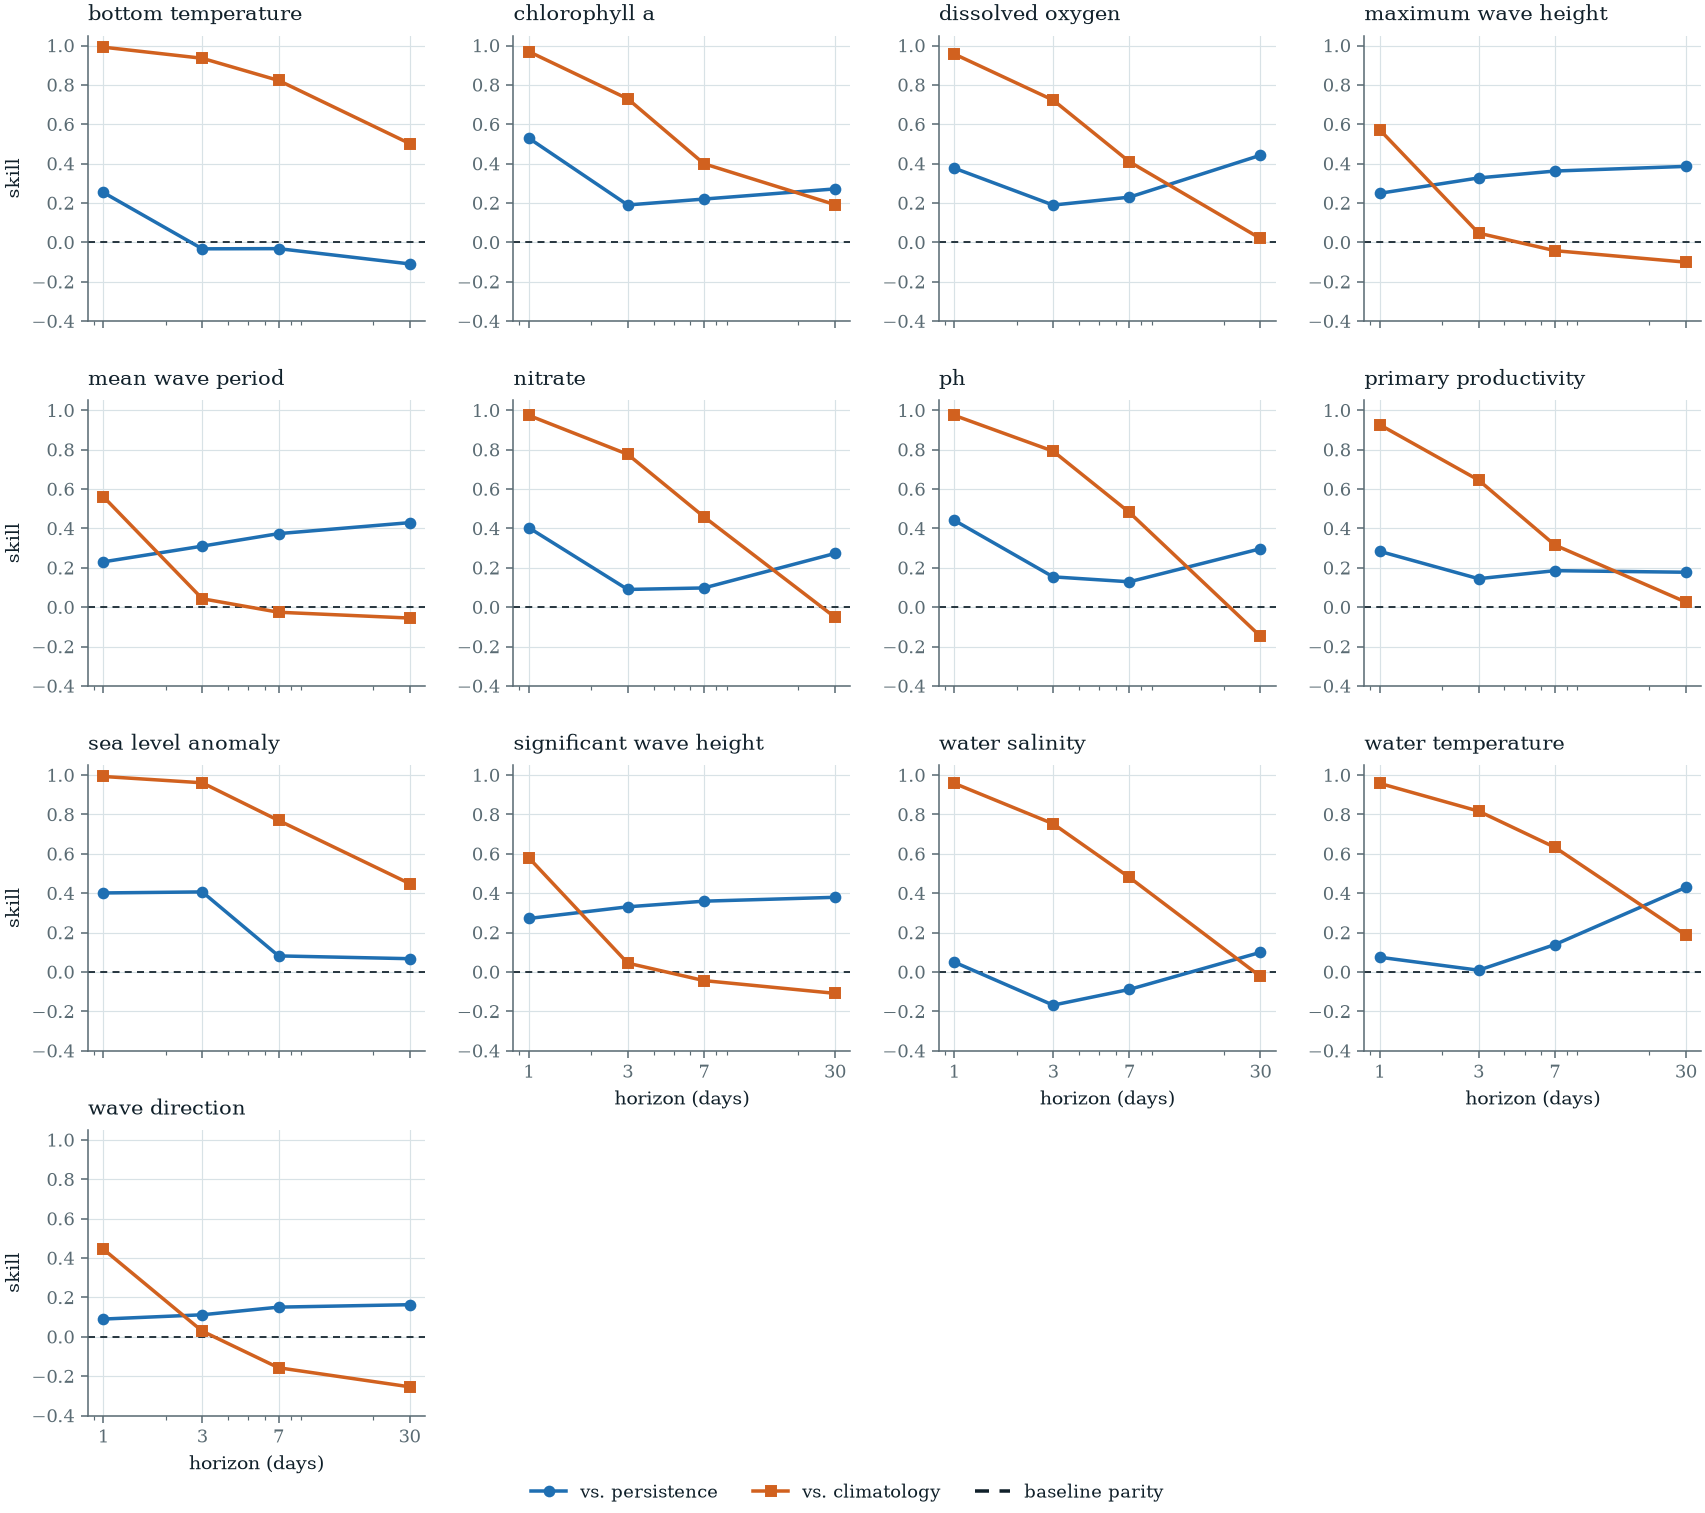

In [4]:
variables = sorted(main["variable"].unique())
cols = 4
rows_n = int(np.ceil(len(variables) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(12.5, 2.7 * rows_n), sharex=True)
axes = np.atleast_2d(axes)

for i, var in enumerate(variables):
    ax = axes[i // cols][i % cols]
    s = main[main["variable"] == var].sort_values("horizon")
    ax.axhline(0, color=mv.INK, linewidth=0.9, linestyle=(0, (4, 3)), zorder=1)
    ax.plot(s["horizon"], s["skill_p"], marker="o", color=mv.PERSISTENCE, zorder=3)
    ax.plot(s["horizon"], s["skill_c"], marker="s", color=mv.CLIMATOLOGY, zorder=3)
    ax.set_xscale("log"); ax.set_xticks(HORIZONS)
    ax.set_xticklabels([str(h) for h in HORIZONS])
    ax.set_ylim(-0.4, 1.05)
    ax.set_title(mv.pretty(var))

for i in range(len(variables), rows_n * cols):
    axes[i // cols][i % cols].axis("off")
for c in range(cols):
    occupied = [r for r in range(rows_n) if r * cols + c < len(variables)]
    if occupied:
        axes[occupied[-1]][c].set_xlabel("horizon (days)")
        axes[occupied[-1]][c].tick_params(labelbottom=True)
for r in range(rows_n):
    if r * cols < len(variables):
        axes[r][0].set_ylabel("skill")

handles = [plt.Line2D([], [], color=mv.PERSISTENCE, marker="o", label="vs. persistence"),
           plt.Line2D([], [], color=mv.CLIMATOLOGY, marker="s", label="vs. climatology"),
           plt.Line2D([], [], color=mv.INK, linestyle=(0, (4, 3)), label="baseline parity")]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.015))
fig.tight_layout()
mv.save(fig, "04_all_variables")
plt.show()

## The consequential cases

Models that **beat persistence and lose to climatology**. Under a
persistence-only reporting convention every one of these reads as a success,
when the correct operational decision is to ship the climatology instead —
cheaper to compute, cheaper to serve, and more accurate.

In [5]:
flattered = (main[(main["skill_p"] > 0) & (main["skill_c"] < 0)]
             .sort_values("skill_c")
             [["variable", "horizon", "skill_p", "skill_c", "rmse",
               "persistence_rmse", "climatology_rmse"]])
print(f"{len(flattered)} of {len(main)} model-horizon combinations")
flattered.round(3).reset_index(drop=True)

11 of 52 model-horizon combinations


,variable,horizon,skill_p,skill_c,rmse,persistence_rmse,climatology_rmse
0,wave_direction,30,0.163,-0.254,52.501,57.387,47.126
1,wave_direction,7,0.151,-0.157,49.103,53.278,45.722
2,ph,30,0.297,-0.148,0.016,0.019,0.015
3,significant_wave_height,30,0.379,-0.108,0.760,0.965,0.682
4,maximum_wave_height,30,0.386,-0.100,1.415,1.805,1.273
5,mean_wave_period,30,0.429,-0.055,1.155,1.529,1.128
6,nitrate,30,0.273,-0.051,1.008,1.182,0.975
7,significant_wave_height,7,0.360,-0.044,0.707,0.883,0.679
8,maximum_wave_height,7,0.362,-0.042,1.316,1.648,1.268
9,mean_wave_period,7,0.374,-0.026,1.134,1.433,1.117


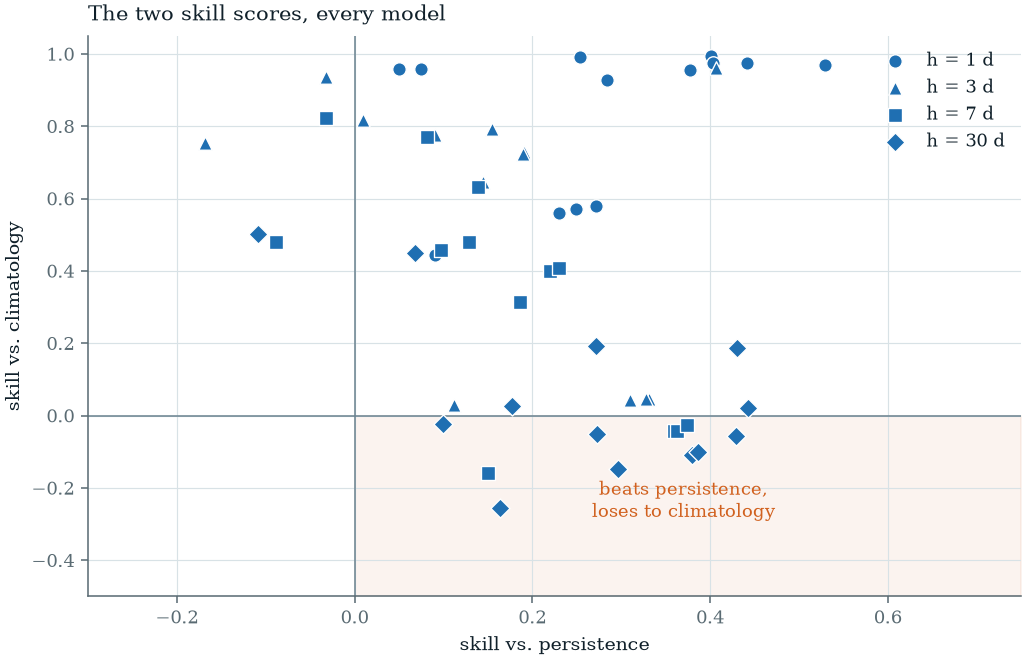

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 5.2))
ax.axhline(0, color=mv.MUTED, linewidth=0.8)
ax.axvline(0, color=mv.MUTED, linewidth=0.8)
ax.fill_between([0, 0.75], -0.5, 0, color=mv.CLIMATOLOGY, alpha=0.07, zorder=0)
markers = {1: "o", 3: "^", 7: "s", 30: "D"}
for h, mk in markers.items():
    s = main[main["horizon"] == h]
    ax.scatter(s["skill_p"], s["skill_c"], marker=mk, s=48,
               facecolor=mv.PERSISTENCE, edgecolor="white", linewidth=0.7,
               label=f"h = {h} d", zorder=3)
ax.annotate("beats persistence,\nloses to climatology", (0.37, -0.28),
            ha="center", fontsize=9.5, color=mv.CLIMATOLOGY)
ax.set(xlabel="skill vs. persistence", ylabel="skill vs. climatology",
       xlim=(-0.3, 0.75), ylim=(-0.5, 1.05),
       title="The two skill scores, every model")
ax.legend()
mv.save(fig, "04_quadrants")
plt.show()

## Where the framework fails outright

Models worse than doing nothing at all. These concentrate in the high-inertia
subsurface variables — exactly the ones notebook 01 flagged from their
autocorrelation, before any model existed.

In [7]:
main[main["skill_p"] < 0].sort_values("skill_p")[
    ["variable", "horizon", "skill_p", "skill_c"]].round(3).reset_index(drop=True)

,variable,horizon,skill_p,skill_c
0,water_salinity,3,-0.168,0.753
1,bottom_temperature,30,-0.109,0.502
2,water_salinity,7,-0.089,0.480
3,bottom_temperature,3,-0.033,0.935
4,bottom_temperature,7,-0.032,0.823


### Testing notebook 01's hypothesis

Notebook 01 suggested that autocorrelation at the forecast horizon might
predict whether persistence can be beaten. It is a natural shortcut, so it is
worth testing properly rather than asserting — across all 52 model-horizon
pairs, comparing autocorrelation at lag *h* against skill at horizon *h*.

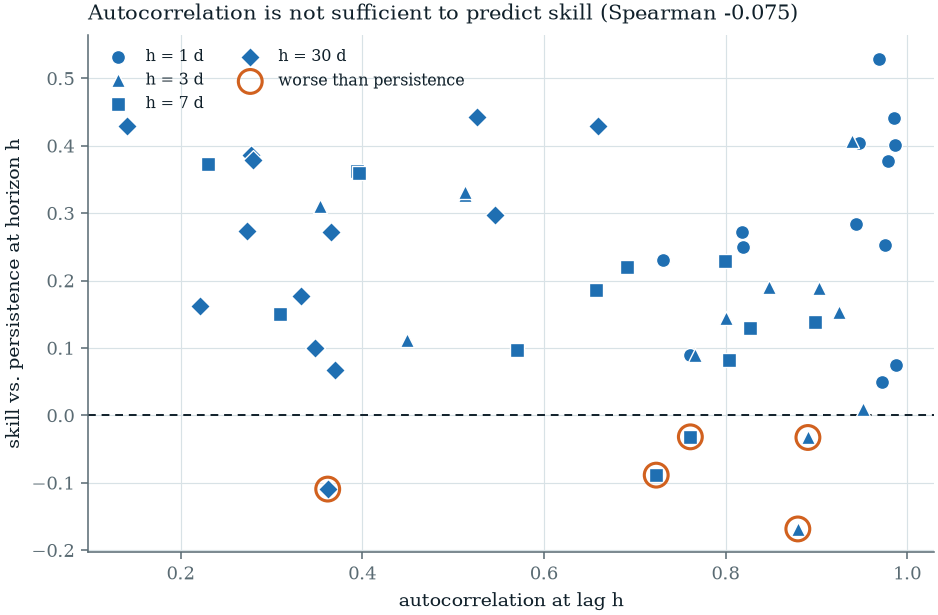

pooled Spearman over 52 pairs : -0.075
  h=1   Spearman +0.225
  h=3   Spearman -0.214
  h=7   Spearman -0.560
  h=30  Spearman +0.088

mean autocorrelation, failures  : 0.723
mean autocorrelation, successes : 0.654


In [8]:
series_raw = mv.load_series()
acf_curves = {}
for var in variables:
    p = mv.target_panel(series_raw, var)
    acf_curves[var] = np.nanmean(
        [mv.autocorrelation(p[s], 30) for s in p.columns], axis=0)

pairs = []
for var in variables:
    for h in HORIZONS:
        row = main[(main["variable"] == var) & (main["horizon"] == h)]
        if len(row):
            pairs.append({"variable": var, "horizon": h,
                          "acf_at_h": float(acf_curves[var][h]),
                          "skill_p": float(row["skill_p"].iloc[0])})
pairs = pd.DataFrame(pairs)

rho = pairs[["acf_at_h", "skill_p"]].corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.axhline(0, color=mv.INK, linewidth=1.0, linestyle=(0, (4, 3)))
markers = {1: "o", 3: "^", 7: "s", 30: "D"}
for h, mk in markers.items():
    s = pairs[pairs["horizon"] == h]
    ax.scatter(s["acf_at_h"], s["skill_p"], marker=mk, s=52,
               facecolor=mv.PERSISTENCE, edgecolor="white", linewidth=0.7,
               zorder=3, label=f"h = {h} d")
fails = pairs[pairs["skill_p"] < 0]
ax.scatter(fails["acf_at_h"], fails["skill_p"], s=150, facecolor="none",
           edgecolor=mv.CLIMATOLOGY, linewidth=1.6, zorder=4,
           label="worse than persistence")
ax.set(xlabel="autocorrelation at lag h", ylabel="skill vs. persistence at horizon h",
       title=f"Autocorrelation is not sufficient to predict skill (Spearman {rho:+.3f})")
ax.legend(ncol=2, fontsize=8)
mv.save(fig, "04_acf_vs_skill")
plt.show()

print(f"pooled Spearman over {len(pairs)} pairs : {rho:+.3f}")
for h in HORIZONS:
    s = pairs[pairs["horizon"] == h]
    print(f"  h={h:<3} Spearman {s[['acf_at_h','skill_p']].corr(method='spearman').iloc[0,1]:+.3f}")
print()
print(f"mean autocorrelation, failures  : {fails['acf_at_h'].mean():.3f}")
print(f"mean autocorrelation, successes : {pairs[pairs.skill_p > 0]['acf_at_h'].mean():.3f}")

**The hypothesis does not survive.** Pooled Spearman is
essentially zero, and the per-horizon values swing in both directions. So
autocorrelation alone is *not* a usable predictor of skill, and the tempting
shortcut — "check the ACF, skip the experiment" — does not work.

What remains true is narrower and still useful. All four short-horizon failures
sit at autocorrelation above 0.72, and the failing variables are among the most
autocorrelated in the set. But `water_temperature` is equally autocorrelated and
succeeds, so high autocorrelation is a **risk factor, not a determinant**: it
tells you the baseline will be strong, not that the model will lose to it.

Whatever separates `water_temperature` from `bottom_temperature` is not memory
length — a plausible candidate is how much of the variance is seasonal rather
than stochastic, since water temperature has by far the stronger annual cycle
(notebook 01). Establishing that would need a decomposition this study does not
attempt, so it is left as an open question rather than a claim.

## Spatial transfer — leave-one-site-out

Serving one globally pooled model at arbitrary coordinates assumes it
generalises to ocean it never saw, rather than interpolating among its training
sites. Tested directly: for each variable, horizon and site, refit on the other
23 and score the held-out one.

The split is blocked in **space and time**: train on the earlier 80% at the 23
retained sites, test on the later 20% at the held-out site. A purely spatial
hold-out would train on the same dates it tests on, measuring interpolation
across a shared period rather than transfer.

In [9]:
at7 = loso[loso["horizon"] == 7]
pooled7 = main[main["horizon"] == 7]
print(f"median skill, sites seen in training : {pooled7['skill_p'].median():+.3f}")
print(f"median skill, held-out sites         : {at7['skill_score'].median():+.3f}")
print(f"held-out fits keeping positive skill : {100 * (at7['skill_score'] > 0).mean():.1f}%")

median skill, sites seen in training : +0.151
median skill, held-out sites         : +0.050
held-out fits keeping positive skill : 56.4%


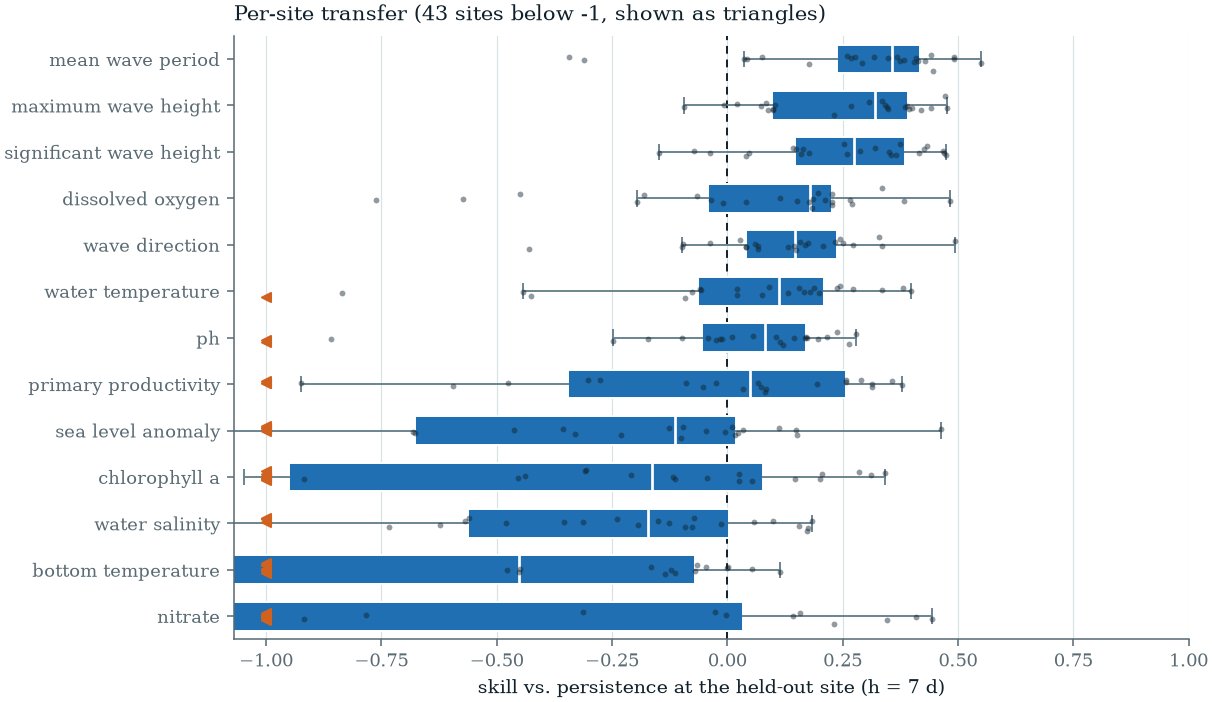

In [10]:
order = (at7.groupby("variable")["skill_score"].median().sort_values().index.tolist())
data = [at7[at7["variable"] == v]["skill_score"].dropna() for v in order]
floor = -1.0

fig, ax = plt.subplots(figsize=(8.8, 5.6))
ax.axvline(0, color=mv.INK, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
bp = ax.boxplot(data, positions=np.arange(len(order)), orientation="horizontal",
                widths=0.62, patch_artist=True, showfliers=False,
                medianprops={"color": "white", "linewidth": 1.4},
                whiskerprops={"color": mv.MUTED}, capprops={"color": mv.MUTED})
for patch in bp["boxes"]:
    patch.set_facecolor(mv.PERSISTENCE); patch.set_edgecolor("white")

rng = np.random.default_rng(0)
off = 0
for i, values in enumerate(data):
    jitter = np.full(len(values), i) + rng.normal(0, 0.07, len(values))
    inside = values >= floor
    ax.scatter(values[inside], jitter[inside], s=9, color=mv.INK, alpha=0.45,
               zorder=4, linewidths=0)
    off += int((~inside).sum())
    if (~inside).any():
        ax.scatter(np.full(int((~inside).sum()), floor), jitter[~inside],
                   s=22, color=mv.CLIMATOLOGY, marker="<", zorder=5)
ax.set(yticks=np.arange(len(order)), xlim=(floor - 0.07, 1.0),
       xlabel="skill vs. persistence at the held-out site (h = 7 d)",
       title=f"Per-site transfer ({off} sites below {floor:.0f}, shown as triangles)")
ax.set_yticklabels([mv.pretty(v) for v in order])
ax.grid(axis="y", visible=False)
mv.save(fig, "04_loso_distribution")
plt.show()

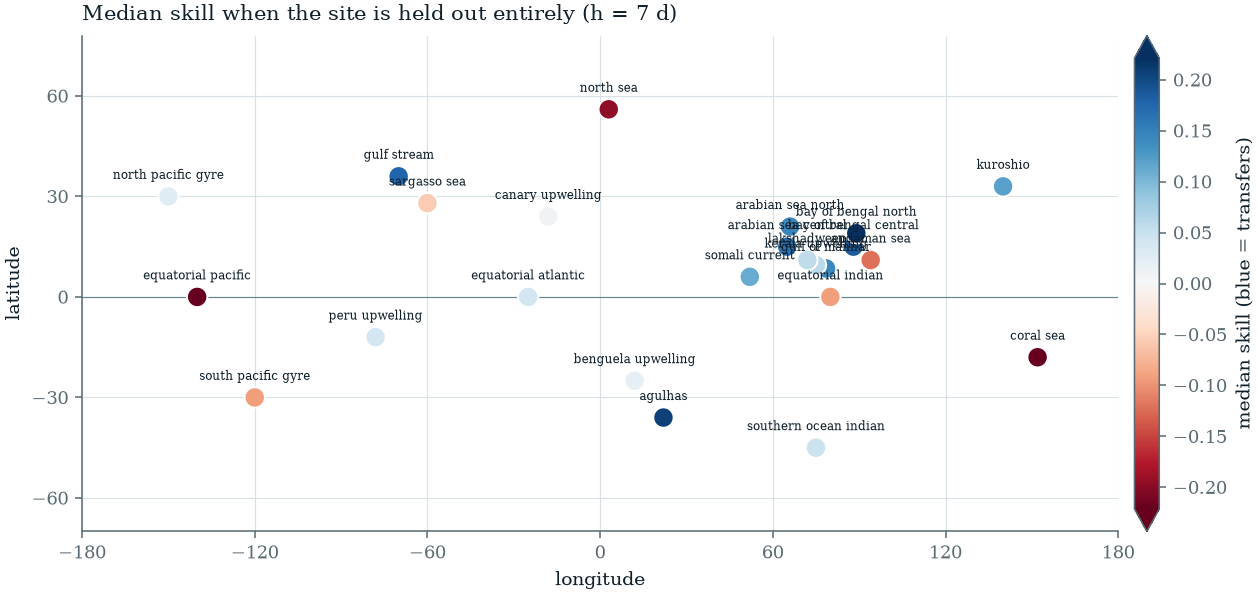

In [11]:
by_site = (at7.groupby("site")
           .agg(latitude=("latitude", "first"), longitude=("longitude", "first"),
                skill=("skill_score", "median")).reset_index())
bound = float(np.nanpercentile(np.abs(by_site["skill"]), 90)) or 0.2

fig, ax = plt.subplots(figsize=(10, 4.6))
sc = ax.scatter(by_site["longitude"], by_site["latitude"], c=by_site["skill"],
                cmap=mv.DIVERGING, vmin=-bound, vmax=bound, s=110,
                edgecolor="white", linewidth=1.0, zorder=3)
for _, r in by_site.iterrows():
    ax.annotate(mv.pretty(r["site"]), (r["longitude"], r["latitude"]),
                xytext=(0, 9), textcoords="offset points", ha="center",
                fontsize=6, color=mv.INK)
ax.axhline(0, color=mv.MUTED, linewidth=0.6, zorder=1)
ax.set(xlim=(-180, 180), ylim=(-70, 78), xlabel="longitude", ylabel="latitude",
       xticks=range(-180, 181, 60), yticks=range(-60, 79, 30),
       title="Median skill when the site is held out entirely (h = 7 d)")
fig.colorbar(sc, ax=ax, pad=0.015, fraction=0.03, extend="both",
             label="median skill (blue = transfers)")
mv.save(fig, "04_site_map")
plt.show()

Transfer is real but it costs skill, and the cost is concentrated in
dynamically energetic regions — western boundary currents and upwelling systems,
whose variability is driven by mesoscale processes a model fitted on distant
sites cannot resolve.

The majority staying positive supports serving the pooled model at unseen
coordinates. The falling median means **pooled metrics overstate what a user
clicking on open ocean should expect**, and a deployed system should say so.

## What to do with two numbers

| $S_{\text{pers}}$ | $S_{\text{clim}}$ | Verdict |
| --- | --- | --- |
| < 0 | any | **Do not deploy.** Persistence is cheaper and better. Typical of high-inertia variables. |
| > 0 | < 0 | **Seasonal artefact.** Ship the climatology instead. Invisible if only $S_{\text{pers}}$ is reported. |
| > 0 | > 0, falling with horizon | **Partly seasonal.** Report the horizon at which it crosses. |
| > 0 | > 0, holding | **Genuine skill** — then check it transfers to a held-out site. |

## Takeaways

1. **The two baselines support opposite conclusions about the same
   predictions.** Persistence-referenced skill is flat with horizon;
   climatology-referenced skill falls monotonically, for 13 of 13 variables.
2. **Eleven model–horizon combinations beat persistence while losing to
   climatology.** Under the common convention all eleven read as successes.
3. **Five are worse than doing nothing**, concentrated in the two most
   strongly autocorrelated variables — though autocorrelation alone turns out
   *not* to predict skill in general (Spearman ~0), so it flags risk rather
   than deciding the outcome.
4. **Pooled models do transfer**, with most held-out sites keeping positive
   skill — but at a real cost that pooled metrics hide, largest exactly in the
   regions users care about most.

The manuscript built from these results is in `research/papers/` (Springer LNCS
and IEEE conference formats).